In [3]:
from statistics import LinearRegression

import numpy as np
import pandas as pd

In [4]:
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('job_salary_prediction_dataset.csv', usecols = ['experience_years', 'skills_count', 'salary'])

In [6]:
df.head(5)

,experience_years,skills_count,salary
0,10,2,109413
1,5,17,93764
2,18,4,148123
3,19,13,189123
4,15,7,165069


In [7]:
df.isnull().sum()

experience_years    0
skills_count        0
salary              0
dtype: int64

In [8]:
df.head(1)

,experience_years,skills_count,salary
0,10,2,109413


In [9]:
X = df.iloc[:,0:2] # experience_years	skills_count
y = df.iloc[:,2] # Output col

In [10]:
df.shape

(250000, 3)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [22]:
X_train.sample(5)

,experience_years,skills_count
123817,10,3
14206,15,19
86725,7,9
41065,17,13
201047,13,7


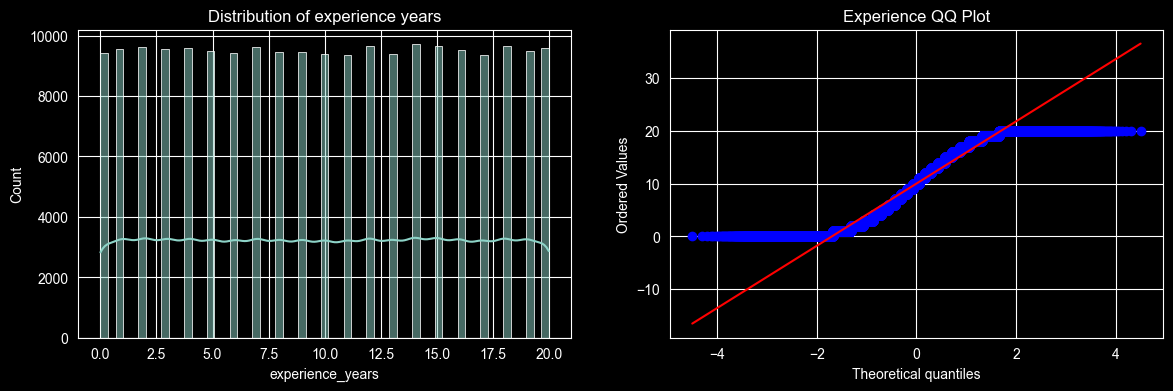

In [13]:
plt.figure(figsize=(14,4))
plt.subplot(121)
# sns.distplot(X_train['experience_years'])
sns.histplot(X_train['experience_years'], kde=True)
plt.title('Distribution of experience years')

plt.subplot(122)
stats.probplot((X_train['experience_years']), dist='norm', plot=plt)
plt.title('Experience QQ Plot')
plt.show()

In [14]:
df.head(1)

,experience_years,skills_count,salary
0,10,2,109413


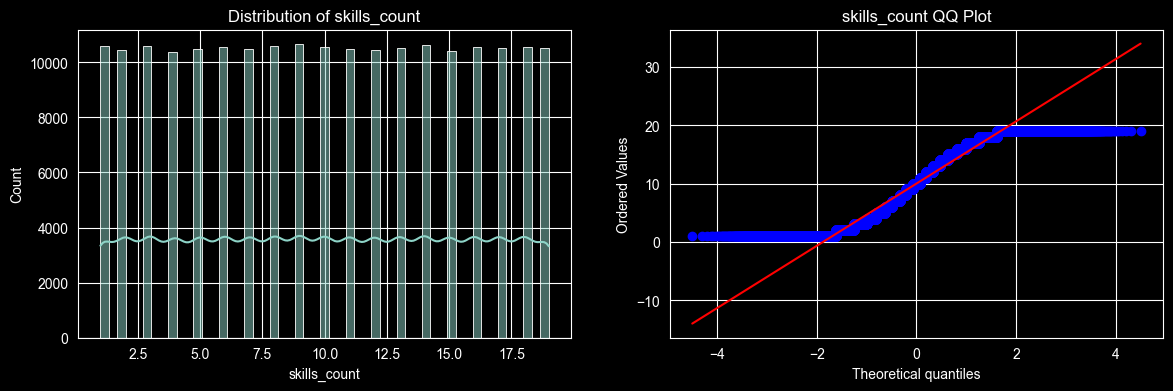

In [15]:
plt.figure(figsize=(14,4))
plt.subplot(121)
# sns.distplot(X_train['skills_count'])
sns.histplot(X_train['skills_count'], kde=True)
plt.title('Distribution of skills_count')

plt.subplot(122)
stats.probplot((X_train['skills_count']), dist='norm', plot=plt)
plt.title('skills_count QQ Plot')
plt.show()

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

clf = LinearRegression()
clf2 = DecisionTreeRegressor()

In [17]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Decision Tree R2:", r2_score(y_test, y_pred1))

Linear Regression R2: 0.20461090578276242
Decision Tree R2: 0.203438561436726


In [18]:
trf = FunctionTransformer(func=np.log1p)

In [19]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score

clf = LinearRegression()
clf2 = DecisionTreeRegressor()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Decision Tree R2:", r2_score(y_test, y_pred1))

Linear Regression R2: 0.17929400192481637
Decision Tree R2: 0.203438561436726
